# Notebook 02 · Modelado

El dataset tiene un desbalance de 19:1 (95% sin ictus / 5% con ictus). Accuracy no es una métrica válida. Usamos AUC-ROC y REcall como métricas principales para minimizar falsos negativos.

---
## Indice
1. Setup e importaciones
2. Configuracion de MLflow
3. Dataset con Feature Engineering opcional
4. Preprocesado y Pipeline
5. Funciones auxiliares
6. `evaluate_with_cv_and_threshold` — CV manual con busqueda de threshold
7. `train_final_model` y `evaluate_on_test`
8. `log_to_mlflow` y `run_experiment`
9. Definicion de modelos
10. Ejecucion de experimentos
11. Comparativa local
12. Optuna
13. Comparación final de modelos optimizados y selección del ganador


---
## 01 · Setup e importaciones

Cargamos todas las dependencias necesarias. Hay dos puntos clave aquí:
* Usamos <code>imblearn.pipeline.Pipeline</code> en lugar de <code>sklearn.pipeline.Pipeline</code> — esto es fundamental porque la versión de imbalanced-learn sabe que SMOTE solo debe aplicarse durante el <code>fit()</code>, nunca durante el <code>predict()</code> ni en el test set.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, roc_auc_score,
    recall_score, f1_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, average_precision_score, fbeta_score
)

from xgboost import XGBClassifier

# ⚠️ imblearn.pipeline — no sklearn.pipeline
# Garantiza que SMOTE solo actua en fit(), nunca en predict()
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE    = 0.2
AUTHOR       = 'Jonathan'

LOG_BASELINE     = True   # True  → re-loguea los 13 runs baseline en MLflow
                           # False → salta el logging (ya están registrados)

# ── Setup Optuna ──
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)  # silencia trials individuales


print('✓ Setup completado')

/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


✓ Setup completado


/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 02 · Configuración de MLflow

Usamos MLflow para hacer tracking de experimentos. Cada vez que se entrena un modelo, MLflow guarda automáticamente los parámetros, métricas y el modelo serializado. Esto nos permite:
* Reproducir cualquier experimento anterior con exactamente los mismos parámetros
* Comparar todos los modelos del equipo en una sola tabla
* Versionar los modelos y descargar el mejor para producción

Para ver la UI ejecutar en terminal (Solo con WSL): <code>mlflow ui --backend-store-uri file:///mnt/c/Users/under/Documents/F5/3_Projects/Stroker_project/mlruns --port 5001</code> y abrir <code>http://localhost:5001</code>


In [ ]:
# ── Configuración MLflow ──
MLFLOW_URI      = 'file:///mnt/c/Users/under/Documents/F5/3_Projects/Stroker_project/mlruns'
EXPERIMENT_NAME = 'Stroke_project_experiments'
OPTUNA_EXP_NAME  = 'Ictus_Project'  # experimento separado para Optuna

mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

ASSETS_DIR = Path().resolve().parent / 'assets' / 'V1'
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ MLflow configurado")

2026/04/22 12:10:42 INFO mlflow.tracking.fluent: Experiment with name 'Prueba1_stroke_project_ex' does not exist. Creating a new experiment.


✓ MLflow configurado


---

## 03 · Carga y versiones del dataset

<code>get_dataset()</code> centraliza toda la lógica de limpieza en un solo lugar. Si el equipo decide cambiar. Solo hay que modificar esta función y todos los experimentos se actualizan automáticamente.

In [3]:
df = pd.read_csv('../data/raw/stroke_dataset.csv')
print(f'✓ {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'  Stroke=1: {df["stroke"].sum()} ({df["stroke"].mean()*100:.1f}%)')


def get_dataset(version: str = 'full', add_features: bool = False) -> pd.DataFrame:
    """
    Carga y limpia el dataset segun decisiones del EDA.

    Versiones
    ---------
    'full'   -> todos los pacientes
    'adults' -> solo age >= 17

    Feature Engineering (opcional)
    ------------------------------
    add_features=True añade variables derivadas. Se loguea en MLflow
    para comparar si mejoran el modelo.

    Features añadidas:
    - age_group     : binning de edad (child/young/adult/senior)
    - high_risk     : flag si tiene hipertension O enfermedad cardiaca
    - age_glucose   : interaccion edad x glucosa (ambas correlacionadas con ictus)
    """
    assert version in ('full', 'adults'), f"version debe ser 'full' o 'adults'"

    df_copy = df.copy()

    # Limpieza EDA: work_type='children' -> 'not_applied'
    df_copy.loc[df_copy['work_type'] == 'children', 'work_type'] = 'not_applied'

    # Sin columna 'group' — age ya es feature numerica continua

    if version == 'adults':
        before = len(df_copy)
        df_copy = df_copy[df_copy['age'] >= 17].copy()
        print(f'  Filtro adults: {before - len(df_copy)} filas eliminadas')

    if add_features:
        # 1. Binning de edad: captura relacion no lineal entre edad y riesgo
        df_copy['age_group'] = pd.cut(
            df_copy['age'],
            bins=[0, 17, 40, 60, 100],
            labels=['child', 'young', 'adult', 'senior']
        ).astype(str)  # string para que el ColumnTransformer lo trate como categorica

        # 2. Flag riesgo medico combinado
        df_copy['high_risk'] = (
            (df_copy['hypertension'] == 1) | (df_copy['heart_disease'] == 1)
        ).astype(int)

        # 3. Interaccion edad x glucosa (ambas con alta correlacion con stroke segun EDA)
        df_copy['age_glucose'] = df_copy['age'] * df_copy['avg_glucose_level']

    print(f"✓ Dataset '{version}' | add_features={add_features}: {df_copy.shape[0]:,} filas")
    return df_copy

✓ 4,981 filas x 11 columnas
  Stroke=1: 248 (5.0%)


---

## 04 · Preprocesado y Pipeline

Realizamos transformaciones distintas a cada grupo de columnas en paralelo:

* Numéricas → StandardScaler: centra en media 0 y escala a desviación 1. Necesario para Logistic Regression (sensible a la escala). 
* Random Forest y XGBoost no lo necesitan.
* Categóricas → OneHotEncoder: convierte categorías en columnas binarias. <code>handle_unknown='ignore'</code> evita errores si en producción llega una categoría no vista en entrenamiento.


El Pipeline encadena pasos en orden. Cuando llamamos a <code>pipeline.fit(X_train, y_train)</code>, cada paso se ejecuta en secuencia:

> prep → [smote] → model

In [4]:
def build_preprocessor(X_train: pd.DataFrame, model_ty="linear") -> ColumnTransformer:
    """
    Construye ColumnTransformer sobre X_train unicamente.
    Aprende media/std y categorias solo del train, nunca del test.

    model_ty
    --------
    'linear' -> StandardScaler en numericas (LR es sensible a la escala)
    'tree'   -> passthrough en numericas (RF y XGBoost no necesitan escalado)
    """
    cat_cols = X_train.select_dtypes(include="object").columns.tolist()
    num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

    if model_ty == "linear":
        num_transformer = StandardScaler()
    else:
        num_transformer = "passthrough"

    preprocessor = ColumnTransformer([
        ("num", num_transformer, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

    return preprocessor


def build_pipeline(model, preprocessor, use_smote: bool = False, sampler=None) -> Pipeline:
    """
    Pipeline: prep -> [sampler] -> model

    - use_smote=True → usa SMOTE por defecto
    - sampler → permite pasar otro sampler (ej: ADASYN)
    """

    steps = [('prep', preprocessor)]

    # Prioridad: sampler explícito
    if sampler is not None:
        steps.append(('sampler', sampler))  
    elif use_smote:
        steps.append(('sampler', SMOTE(random_state=RANDOM_STATE)))

    steps.append(('model', model))
    return Pipeline(steps)


print('✓ build_preprocessor y build_pipeline definidos')

✓ build_preprocessor y build_pipeline definidos


---
## 05. Funciones auxiliares

Tres funciones que nos ayudan en nuestro pipeline

In [5]:
def get_model_ty(model) -> str:
    """Devuelve el tipo de modelo para seleccionar el preprocesador adecuado."""
    return 'tree' if isinstance(model, (RandomForestClassifier, XGBClassifier)) else 'linear'


def get_scale_pos_weight(y) -> float:
    """
    Calcula el peso para compensar el desbalance en XGBoost.
    scale_pos_weight = n_negativos / n_positivos
    Equivalente a class_weight='balanced' en sklearn.
    Solo se usa cuando no hay SMOTE (si hay SMOTE, el dataset ya esta balanceado).
    """
    neg, pos = (y == 0).sum(), (y == 1).sum()
    return neg / pos


def find_best_threshold(y_true, y_prob) -> float:
    """
    Busca el umbral de decision que maximiza F-beta (beta=2).

    Por que F-beta con beta=2:
    - beta=2 pondera el Recall dos veces mas que la Precision.
    - En contexto medico de cribado, un falso negativo (no detectar
      un paciente en riesgo) es mucho mas costoso que un falso positivo.
    - beta=2 refleja esa asimetria de costes.

    Parametros
    ----------
    y_true : array de etiquetas reales
    y_prob : array de probabilidades predichas (clase positiva)

    """
    best_t     = 0.5
    best_score = 0.0

    for t in np.linspace(0.01, 0.99, 200):
        y_pred = (y_prob >= t).astype(int)

        # Evitar division por cero si el umbral es extremo
        if y_pred.sum() == 0:
            continue

        score = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        if score > best_score:
            best_score = score
            best_t     = t

    return best_t


print('✓ Funciones auxiliares definidas')

✓ Funciones auxiliares definidas


---

## 06 · Función evaluate_with_cv_and_threshold

Esta es la funcion clave del notebook. Reemplaza evaluate_with_cv porque cross_validate no da acceso a las probabilidades por fold — y sin ellas no se puede buscar el threshold en validacion. El CV manual con cv.split() lo permite.

1. Entrena en train_fold
2. Obtiene y_prob en val_fold
3. Busca threshold optimo en val_fold con fbeta(beta=2)
4. Calcula metricas con ese threshold

> Promedia threshold y metricas → aplica en test


In [6]:
def evaluate_with_cv_and_threshold(model, X_train: pd.DataFrame, y_train: pd.Series, use_smote: bool = False) -> dict:
    """
    Sin data leakage:
    El threshold se busca en el fold de VALIDACION de cada iteracion.
    El test set nunca participa en este proceso.
    El threshold final es el promedio de los 5 folds.

    Parametros
    ----------
    model     : estimador sklearn
    X_train   : features de entrenamiento (sin test)
    y_train   : target de entrenamiento (sin test)
    use_smote : bool
    
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    fold_auc, fold_recall, fold_f1, fold_thresholds = [], [], [], []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):

        X_tr  = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Clonar modelo para que cada fold sea independiente
        model_fold = clone(model)

        # XGBoost sin SMOTE necesita scale_pos_weight calculado sobre ESTE fold
        if isinstance(model_fold, XGBClassifier) and not use_smote:
            model_fold.set_params(scale_pos_weight=get_scale_pos_weight(y_tr))

        # Preprocesador y pipeline sobre el fold de entrenamiento
        preprocessor = build_preprocessor(X_tr, model_ty=get_model_ty(model))
        pipeline_fold = build_pipeline(model_fold, preprocessor, use_smote=use_smote)
        pipeline_fold.fit(X_tr, y_tr)

        # Probabilidades en validacion — nunca en test
        y_prob_val = pipeline_fold.predict_proba(X_val)[:, 1]

        # Buscar threshold optimo en ESTE fold de validacion
        best_t_fold = find_best_threshold(y_val, y_prob_val)
        y_pred_val  = (y_prob_val >= best_t_fold).astype(int)

        # Metricas de este fold con su threshold optimo
        fold_auc.append(roc_auc_score(y_val, y_prob_val))
        fold_recall.append(recall_score(y_val, y_pred_val, zero_division=0))
        fold_f1.append(f1_score(y_val, y_pred_val, zero_division=0))
        fold_thresholds.append(best_t_fold)

    # Este es el valor que aplicaremos en el test set
    avg_threshold = np.mean(fold_thresholds)

    return {
        'cv_auc':         np.mean(fold_auc),
        'cv_auc_std':     np.std(fold_auc),
        'cv_recall':      np.mean(fold_recall),
        'cv_f1':          np.mean(fold_f1),
        'best_threshold': round(avg_threshold, 4),
        'threshold_std':  round(np.std(fold_thresholds), 4),
    }


print('✓ evaluate_with_cv_and_threshold definida')

✓ evaluate_with_cv_and_threshold definida


---
## 07 · train_final_model y evaluate_on_test

1. Entrena el modelo final sobre todos los datos de train.
2. Evaluar el modelo con test

In [7]:
def train_final_model(model, X_train: pd.DataFrame, y_train: pd.Series, use_smote: bool = False):
    """
    Entrena el modelo final sobre todos los datos de train.

    Una vez que el CV ha validado los hiperparametros y encontrado
    el threshold optimo, entrenamos sobre el train completo para
    aprovechar todos los datos disponibles antes de evaluar en test.

    Retorna
    -------
    pipeline : Pipeline ajustado
    scale_pos_weight : float o None
    """
    model_final      = clone(model)
    scale_pos_weight = None

    if isinstance(model_final, XGBClassifier) and not use_smote:
        scale_pos_weight = get_scale_pos_weight(y_train)
        model_final.set_params(scale_pos_weight=scale_pos_weight)

    preprocessor = build_preprocessor(X_train, model_ty=get_model_ty(model))
    pipeline      = build_pipeline(model_final, preprocessor, use_smote=use_smote)
    pipeline.fit(X_train, y_train)

    return pipeline, scale_pos_weight

print('✓ train_final_model definido')

✓ train_final_model definido


In [8]:

def evaluate_on_test(pipeline, X_test: pd.DataFrame, y_test: pd.Series, threshold: float = 0.5) -> tuple:
    """
    Evalua el modelo en el test set con el threshold encontrado en CV.

    El threshold viene de evaluate_with_cv_and_threshold, nunca se
    busca sobre el test set (eso seria data leakage).

    Retorna
    -------
    metrics  : dict con AUC, recall, F1, precision, PR-AUC
    y_pred   : predicciones binarias con el threshold aplicado
    y_prob   : probabilidades crudas (para graficos ROC)
    """
    y_prob = (
        pipeline.predict_proba(X_test)[:, 1]
        if hasattr(pipeline[-1], 'predict_proba')
        else pipeline.decision_function(X_test)
    )
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        'auc':       roc_auc_score(y_test, y_prob),
        'pr_auc':    average_precision_score(y_test, y_prob),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
    }
    return metrics, y_pred, y_prob


print('✓ Evaluate_on_test definidas')

✓ Evaluate_on_test definidas


---

## 08 · log_to_mlflow y run_experiment

In [9]:
def log_confusion_matrix(y_test, y_pred, title: str = ''):
    """
    Genera y loguea la confusion matrix como artifact en MLflow.
    """
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['No Stroke', 'Stroke']
    ).plot(ax=ax)
    ax.set_title(title)
    path = ASSETS_DIR / f'Confusion_Matrix_{title}.png'
    plt.savefig(path, dpi=100, bbox_inches='tight')
    plt.close()
    mlflow.log_artifact(path)

In [10]:
def log_roc_curve(y_test, y_prob, auc: float, title: str = ''):
    """
    Genera y loguea la curva ROC como artifact en MLflow.
    """
    fig, ax = plt.subplots(figsize=(5, 4))
    RocCurveDisplay.from_predictions(
        y_test, y_prob, ax=ax,
        name=f'AUC = {auc:.3f}'
    )
    ax.set_title(title)
    path = ASSETS_DIR / f'Curve_ROC{title}.png'
    plt.savefig(path, dpi=100, bbox_inches='tight')
    plt.close()
    mlflow.log_artifact(path)


In [ ]:
def log_to_mlflow( model, model_name, dataset_version, use_smote, add_features, cv_metrics, test_metrics,
                   auc_gap, author, pipeline, y_test, y_pred, y_prob, scale_pos_weight, log_artifacts: bool = True):
    """
    Centraliza todo el log a MLflow.

    Separacion de responsabilidades:
    - log_metric  : valores numericos comparables entre runs (metricas)
    - log_param   : hiperparametros del modelo y configuracion
    - set_tag     : metadatos no numericos (autor, tipo de modelo)
    - log_artifact: archivos (imagenes, modelos)
    """
    run_name = f"{model_name}_{dataset_version}_smote={use_smote}_feat={add_features}"

    with mlflow.start_run(run_name=run_name):

        # ── Metricas CV (promediadas sobre 5 folds) ──
        mlflow.log_metric('cv_auc',          round(cv_metrics['cv_auc'], 4))
        mlflow.log_metric('cv_auc_std',      round(cv_metrics['cv_auc_std'], 4))
        mlflow.log_metric('cv_recall',       round(cv_metrics['cv_recall'], 4))
        mlflow.log_metric('cv_f1',           round(cv_metrics['cv_f1'], 4))

        # ── Metricas test (evaluacion final con threshold de CV) ──
        mlflow.log_metric('auc',             round(test_metrics['auc'], 4))
        mlflow.log_metric('pr_auc',          round(test_metrics['pr_auc'], 4))
        mlflow.log_metric('recall',          round(test_metrics['recall'], 4))
        mlflow.log_metric('f1',              round(test_metrics['f1'], 4))
        mlflow.log_metric('precision',       round(test_metrics['precision'], 4))
        mlflow.log_metric('auc_gap_cv_test', round(auc_gap, 4))

        # ── Threshold ──
        mlflow.log_metric('best_threshold', cv_metrics['best_threshold'])
        mlflow.log_metric('threshold_std', cv_metrics['threshold_std'])

        # ── Hiperparametros del modelo ──
        params = model.get_params().copy()
        params.pop('scale_pos_weight', None)  # se loguea por separado
        mlflow.log_params({k: str(v) for k, v in params.items()})

        if scale_pos_weight is not None:
            mlflow.log_param('scale_pos_weight', round(scale_pos_weight, 3))
        mlflow.log_param('use_smote', use_smote)
        mlflow.log_param('add_features', add_features)

        # ── Tags: metadatos, no son hiperparametros ──
        mlflow.set_tag('author', author)
        mlflow.set_tag('model_type', model_name)
        mlflow.set_tag('dataset_version', dataset_version)

        # ── Artifacts ──
        if log_artifacts:
            log_confusion_matrix(y_test, y_pred, title=run_name)
            log_roc_curve(y_test, y_prob, auc=test_metrics['auc'], title=run_name)
            mlflow.sklearn.log_model(pipeline, artifact_path=model_name)


print('✓ log_to_mlflow definida')

✓ log_to_mlflow definida


In [12]:
def run_experiment(model, model_name: str, dataset_version: str = 'full', use_smote: bool = False,
                        author: str = AUTHOR, add_features: bool = False, log_artifacts: bool = True) -> dict:
    """
    Orquesta el flujo completo de un experimento.

    Flujo
    -----
    1. Carga datos (version + feature engineering)
    2. Split estratificado train/test
    3. CV manual: metricas robustas + threshold optimo sin data leakage
    4. Entrenamiento final sobre train completo
    5. Evaluacion en test con el threshold encontrado en CV
    6. Log en MLflow
    7. Retorna dict para comparativa local

    """
    print(f"\n{'='*55}")
    print(f'  {model_name} | {dataset_version} | smote={use_smote} | feat={add_features}')
    print(f"{'='*55}")

    # 1. Datos
    df_exp = get_dataset(dataset_version, add_features=add_features)
    X = df_exp.drop('stroke', axis=1)
    y = df_exp['stroke']

    # Split estratificado: preserva proporcion de clases en ambos splits
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f'  Train: {len(X_train):,} | Test: {len(X_test):,} | Positivos train: {y_train.sum()}')

    # 2. CV con busqueda de threshold en validacion
    cv_metrics = evaluate_with_cv_and_threshold(model, X_train, y_train, use_smote)
    print(f"  CV AUC    : {cv_metrics['cv_auc']:.4f} +/- {cv_metrics['cv_auc_std']:.4f}")
    print(f"  CV Recall : {cv_metrics['cv_recall']:.4f}")
    print(f"  Threshold : {cv_metrics['best_threshold']:.4f} +/- {cv_metrics['threshold_std']:.4f}")

    # 3. Entrenamiento final
    pipeline, scale_pos_weight = train_final_model(model, X_train, y_train, use_smote)

    # 4. Evaluacion en test con el threshold de CV
    best_threshold = cv_metrics['best_threshold']
    test_metrics, y_pred, y_prob = evaluate_on_test(pipeline, X_test, y_test, threshold=best_threshold)

    # Gap CV vs test: indicador de overfitting (debe ser < 0.05)
    auc_gap = abs(cv_metrics['cv_auc'] - test_metrics['auc'])

    print(f"  TEST AUC  : {test_metrics['auc']:.4f} | GAP: {auc_gap:.4f} {'✓' if auc_gap < 0.05 else '⚠️ revisar'}")
    print(f"  TEST Rec  : {test_metrics['recall']:.4f}")
    print(f"  TEST F1   : {test_metrics['f1']:.4f}")
    print(f"  TEST Prec : {test_metrics['precision']:.4f}")
    print(f"  PR-AUC    : {test_metrics['pr_auc']:.4f}")
    print(f'\n{classification_report(y_test, y_pred, target_names=["Sin ictus", "Ictus"])}')

    # 5. Log MLflow
    log_to_mlflow(
        model, model_name, dataset_version, use_smote, add_features,
        cv_metrics, test_metrics, auc_gap, author,
        pipeline, y_test, y_pred, y_prob, scale_pos_weight,
        log_artifacts=log_artifacts
    )
    print('  ✓ Run registrado en MLflow')

    return {
        'model':          model_name,
        'dataset':        dataset_version,
        'smote':          use_smote,
        'add_features':   add_features,
        'threshold':      best_threshold,
        'threshold_std':  cv_metrics['threshold_std'],
        'cv_auc':         round(cv_metrics['cv_auc'], 4),
        'cv_recall':      round(cv_metrics['cv_recall'], 4),
        'cv_f1':          round(cv_metrics['cv_f1'], 4),
        'auc':            round(test_metrics['auc'], 4),
        'pr_auc':         round(test_metrics['pr_auc'], 4),
        'recall':         round(test_metrics['recall'], 4),
        'f1':             round(test_metrics['f1'], 4),
        'precision':      round(test_metrics['precision'], 4),
        'auc_gap':        round(auc_gap, 4),
        '_pipeline':      pipeline,  # para analisis posterior, no va al df
        '_y_test':        y_test,
        '_y_prob':        y_prob,
    }


print('✓ run_experiment definida')

✓ run_experiment definida


---
## 09 · Definicion de modelos

Aquí definimos los modelos y lanzamos los experimentos. Cada llamada a <code>run_experiment</code> genera un run independiente en MLflow con sus propias métricas, parámetros y el modelo serializado.

Guardamos todos los resultados en una lista para generar la comparativa al final (Local). Los mejores modelos con configuracion razonada se usarán en Optuna.


In [ ]:
# ── Logistic Regression ──
lr_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',  # unico solver compatible con L1
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# ── Random Forest ── Variantes para comparar: profundidad libre, controlada y superficial
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    class_weight='balanced', random_state=RANDOM_STATE
)
rf_controlled = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_split=10,
    class_weight='balanced', random_state=RANDOM_STATE
)
rf_shallow = RandomForestClassifier(
    n_estimators=200, max_depth=5,
    class_weight='balanced', random_state=RANDOM_STATE
)

# ── XGBoost ── Variantes: base, deep y regularizado
xgb_base = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_deep = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_reg = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    reg_alpha=1.0, reg_lambda=2.0,  # regularizacion L1+L2 para reducir overfitting
    eval_metric='logloss', random_state=RANDOM_STATE
)

print('✓ Modelos definidos')
print('  LR: 1 variante | RF: 3 variantes | XGBoost: 3 variantes')

✓ Modelos definidos
  LR: 1 variante | RF: 3 variantes | XGBoost: 3 variantes


---
## 10 · Ejecucion de experimentos

Experimentos disenados para responder preguntas concretas:

* ¿Mejora el feature engineering? 
* ¿SMOTE ayuda o no? 
* ¿Que profundidad es mejor en RF?


In [ ]:
results = []

if LOG_BASELINE:
    # ── LR como baseline ──
    results.append(run_experiment(lr_model,      'LR',  'full', use_smote=False, add_features=False))
    results.append(run_experiment(lr_model,      'LR',  'full', use_smote=False, add_features=True))
    results.append(run_experiment(lr_model,      'LR',  'full', use_smote=True,  add_features=False))

    # ── Pregunta 2: RF — profundidad vs generalizacion ──
    results.append(run_experiment(rf_base,       'RF',  'full', use_smote=False, add_features=False))
    results.append(run_experiment(rf_controlled, 'RF',  'full', use_smote=False, add_features=False))
    results.append(run_experiment(rf_shallow,    'RF',  'full', use_smote=False, add_features=False))

    # ── Pregunta 3: RF con features — mejora? ──
    results.append(run_experiment(rf_base,       'RF',  'full', use_smote=False, add_features=True))
    results.append(run_experiment(rf_controlled, 'RF',  'full', use_smote=False, add_features=True))

    # ── Pregunta 4: XGBoost — variantes ──
    results.append(run_experiment(xgb_base,      'XGB', 'full', use_smote=False, add_features=False))
    results.append(run_experiment(xgb_deep,      'XGB', 'full', use_smote=False, add_features=False))
    results.append(run_experiment(xgb_reg,       'XGB', 'full', use_smote=False, add_features=False))

    # ── Pregunta 5: XGBoost con features ──
    results.append(run_experiment(xgb_base,      'XGB', 'full', use_smote=False, add_features=True))
    results.append(run_experiment(xgb_reg,       'XGB', 'full', use_smote=False, add_features=True))

    print(f'\n✓ {len(results)} experimentos completados')
    
else:
    print('LOG_BASELINE=False → baseline skipped. Carga results desde df_results si lo necesitas.')


  LR | full | smote=False | feat=False
✓ Dataset 'full' | add_features=False: 4,981 filas
  Train: 3,984 | Test: 997 | Positivos train: 198
  CV AUC    : 0.8379 +/- 0.0276
  CV Recall : 0.7986
  Threshold : 0.5478 +/- 0.0884
  TEST AUC  : 0.8412 | GAP: 0.0034 ✓
  TEST Rec  : 0.7400
  TEST F1   : 0.2442
  TEST Prec : 0.1462
  PR-AUC    : 0.1711

              precision    recall  f1-score   support

   Sin ictus       0.98      0.77      0.86       947
       Ictus       0.15      0.74      0.24        50

    accuracy                           0.77       997
   macro avg       0.56      0.76      0.55       997
weighted avg       0.94      0.77      0.83       997



2026/04/22 12:10:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 12:10:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Run registrado en MLflow

  LR | full | smote=False | feat=True
✓ Dataset 'full' | add_features=True: 4,981 filas
  Train: 3,984 | Test: 997 | Positivos train: 198
  CV AUC    : 0.8391 +/- 0.0274
  CV Recall : 0.7223
  Threshold : 0.6059 +/- 0.0247
  TEST AUC  : 0.8467 | GAP: 0.0076 ✓
  TEST Rec  : 0.6600
  TEST F1   : 0.2588
  TEST Prec : 0.1610
  PR-AUC    : 0.1743

              precision    recall  f1-score   support

   Sin ictus       0.98      0.82      0.89       947
       Ictus       0.16      0.66      0.26        50

    accuracy                           0.81       997
   macro avg       0.57      0.74      0.58       997
weighted avg       0.94      0.81      0.86       997



2026/04/22 12:11:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 12:11:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Run registrado en MLflow

  LR | full | smote=True | feat=False
✓ Dataset 'full' | add_features=False: 4,981 filas
  Train: 3,984 | Test: 997 | Positivos train: 198
  CV AUC    : 0.8355 +/- 0.0279
  CV Recall : 0.7985
  Threshold : 0.5350 +/- 0.0937
  TEST AUC  : 0.8373 | GAP: 0.0018 ✓
  TEST Rec  : 0.7400
  TEST F1   : 0.2434
  TEST Prec : 0.1457
  PR-AUC    : 0.1875

              precision    recall  f1-score   support

   Sin ictus       0.98      0.77      0.86       947
       Ictus       0.15      0.74      0.24        50

    accuracy                           0.77       997
   macro avg       0.56      0.76      0.55       997
weighted avg       0.94      0.77      0.83       997



...

  ✓ Run registrado en MLflow

  XGB | full | smote=False | feat=True
✓ Dataset 'full' | add_features=True: 4,981 filas
  Train: 3,984 | Test: 997 | Positivos train: 198
  CV AUC    : 0.7933 +/- 0.0321
  CV Recall : 0.7878
  Threshold : 0.1952 +/- 0.1328
  TEST AUC  : 0.8307 | GAP: 0.0374 ✓
  TEST Rec  : 0.8200
  TEST F1   : 0.2356
  TEST Prec : 0.1376
  PR-AUC    : 0.1827

              precision    recall  f1-score   support

   Sin ictus       0.99      0.73      0.84       947
       Ictus       0.14      0.82      0.24        50

    accuracy                           0.73       997
   macro avg       0.56      0.77      0.54       997
weighted avg       0.94      0.73      0.81       997



2026/04/22 12:15:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 12:15:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Run registrado en MLflow

  XGB | full | smote=False | feat=True
✓ Dataset 'full' | add_features=True: 4,981 filas
  Train: 3,984 | Test: 997 | Positivos train: 198
  CV AUC    : 0.7937 +/- 0.0325
  CV Recall : 0.7365
  Threshold : 0.2168 +/- 0.1415
  TEST AUC  : 0.8149 | GAP: 0.0213 ✓
  TEST Rec  : 0.7200
  TEST F1   : 0.2338
  TEST Prec : 0.1395
  PR-AUC    : 0.1556

              precision    recall  f1-score   support

   Sin ictus       0.98      0.77      0.86       947
       Ictus       0.14      0.72      0.23        50

    accuracy                           0.76       997
   macro avg       0.56      0.74      0.55       997
weighted avg       0.94      0.76      0.83       997



2026/04/22 12:15:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 12:15:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Run registrado en MLflow

✓ 13 experimentos completados


---

## 11  Comparativa

Comparamos los modelo para encontrar el que mejor se ajuste a lo planteado.

In [ ]:
# Columnas para el df (excluimos las privadas que empiezan con _)
METRIC_COLS = ['model','dataset','smote','add_features','threshold',
               'cv_auc','cv_recall','cv_f1','auc','pr_auc','recall','f1','precision','auc_gap']

df_results = (
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
    .sort_values('cv_auc', ascending=False)
    .reset_index(drop=True)
)

print('\n COMPARATIVA COMPLETA SIN OPTUNA (ordenado por CV AUC)\n')
display(
    df_results[METRIC_COLS].style
    .background_gradient(subset=['cv_auc','cv_recall','cv_f1','auc','recall'], cmap='YlGn')
    .background_gradient(subset=['auc_gap'], cmap='YlOrRd')
    .format({
        col: '{:.4f}' for col in
        ['cv_auc','cv_recall','cv_f1','auc','pr_auc','recall','f1','precision','auc_gap','threshold']
    })
    .set_caption('auc_gap < 0.05 = sin overfitting | verde oscuro = mejor valor')
)


 COMPARATIVA COMPLETA (ordenado por CV AUC)



,model,dataset,smote,add_features,threshold,cv_auc,cv_recall,cv_f1,auc,pr_auc,recall,f1,precision,auc_gap
0,LR,full,False,True,0.6059,0.8391,0.7223,0.2765,0.8467,0.1743,0.6600,0.2588,0.1610,0.0076
1,LR,full,False,False,0.5478,0.8379,0.7986,0.2658,0.8412,0.1711,0.7400,0.2442,0.1462,0.0034
2,LR,full,True,False,0.5350,0.8355,0.7985,0.2615,0.8373,0.1875,0.7400,0.2434,0.1457,0.0018
3,RF,full,False,True,0.2474,0.8183,0.7932,0.2558,0.8343,0.1683,0.7200,0.2353,0.1406,0.0160
4,RF,full,False,False,0.5005,0.8149,0.7372,0.2398,0.8265,0.1517,0.8000,0.2446,0.1444,0.0117
5,RF,full,False,False,0.2927,0.8114,0.7278,0.2582,0.8323,0.1587,0.7400,0.2442,0.1462,0.0209
6,RF,full,False,True,0.0632,0.8015,0.7378,0.2420,0.8013,0.1546,0.7200,0.2432,0.1463,0.0002
7,RF,full,False,False,0.0612,0.7962,0.7324,0.2351,0.8094,0.1526,0.6600,0.2349,0.1429,0.0132
8,XGB,full,False,False,0.2257,0.7950,0.7627,0.2385,0.8263,0.1716,0.7400,0.2263,0.1336,0.0313
9,XGB,full,False,True,0.2168,0.7937,0.7365,0.2356,0.8149,0.1556,0.7200,0.2338,0.1395,0.0213


---
## 12 · Optimización de Hiperparámetros — Optuna

**Estrategia:** 6 estudios independientes (2 por modelo: `add_features=True/False`).  
Optuna busca los mejores hiperparámetros dentro de cada configuración.  
Al final se selecciona el **ganador de cada familia** (LR, RF, XGB) y se loguea en MLflow.

| Modelo | add_features | Trials | Parámetros optimizados |
|--------|-------------|--------|------------------------|
| LR | False / True | 20 cada uno | `C` |
| RF | False / True | 25 cada uno | `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` |
| XGB | False / True | 30 cada uno | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` |

In [ ]:
# Cambiar al experimento de Optuna para no mezclar con los runs baseline
mlflow.set_experiment(OPTUNA_EXP_NAME)

print(f'✓ Optuna configurado')
print(f'  Experimento MLflow : {OPTUNA_EXP_NAME}')
print(f'  Sampler            : TPE (búsqueda bayesiana)')

2026/04/22 12:16:06 INFO mlflow.tracking.fluent: Experiment with name 'Prueba1_stroke_project_op' does not exist. Creating a new experiment.


✓ Optuna configurado
  Experimento MLflow : Prueba1_stroke_project_op
  Sampler            : TPE (búsqueda bayesiana)


### 12.1 · Función objetivo genérica

`make_objective` es una función de orden superior: recibe la configuración fija de cada estudio y devuelve
la función `objective(trial)` que Optuna llama en cada iteración.  
Los trials son **ligeros**: solo CV — sin MLflow, sin artifacts. El logging completo ocurre solo al final sobre el ganador.

In [ ]:
def make_objective(model_factory, add_features: bool, use_smote: bool = False):
    """
    Devuelve una función objective(trial) lista para Optuna.

    model_factory : callable(trial) → modelo sklearn configurado con los params del trial
    add_features  : bool — controla la versión del dataset (se fija por estudio)
    use_smote     : bool — se fija por estudio

    Métrica optimizada: cv_auc (maximize)
    User attrs guardados: cv_recall, threshold, cv_auc_std (para análisis posterior)
    """
    def objective(trial):
        # 1. Construir modelo con los parámetros propuestos por el trial
        model = model_factory(trial)

        # 2. Cargar dataset con la configuración fija de este estudio
        df_exp = get_dataset('full', add_features=add_features)
        X = df_exp.drop('stroke', axis=1)
        y = df_exp['stroke']
        X_tr, _, y_tr, _ = train_test_split(
            X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        # 3. CV ligero — reutiliza evaluate_with_cv_and_threshold del notebook
        metrics = evaluate_with_cv_and_threshold(model, X_tr, y_tr, use_smote=use_smote)

        # 4. Guardar métricas adicionales para inspeccionar después
        trial.set_user_attr('cv_recall',   round(metrics['cv_recall'], 4))
        trial.set_user_attr('cv_auc_std',  round(metrics['cv_auc_std'], 4))
        trial.set_user_attr('threshold',   metrics['best_threshold'])

        return metrics['cv_auc']

    return objective


def run_optuna_study(name: str, objective_fn, n_trials: int) -> optuna.Study:
    """
    Crea y ejecuta un estudio Optuna con barra de progreso.
    """
    print(f'\n  Ejecutando: {name} ({n_trials} trials)...')
    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=name
    )
    study.optimize(objective_fn, n_trials=n_trials, show_progress_bar=True)
    print(f'  ✓ Mejor CV AUC : {study.best_value:.4f}')
    print(f'    CV Recall    : {study.best_trial.user_attrs["cv_recall"]:.4f}')
    print(f'    Threshold    : {study.best_trial.user_attrs["threshold"]:.4f}')
    return study


print('✓ make_objective y run_optuna_study definidas')

✓ make_objective y run_optuna_study definidas


### 12.2 · Logistic Regression — 2 estudios (feat=False / feat=True)

In [20]:
def lr_factory(trial) -> LogisticRegression:
    """Espacio de búsqueda LR: solo C en escala log."""
    return LogisticRegression(
        C=trial.suggest_float('C', 1e-3, 10.0, log=True),
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )


print('── LR Optuna ────────────────────────────────────────')

study_lr_nofeat = run_optuna_study(
    'lr_feat_false',
    make_objective(lr_factory, add_features=False),
    n_trials=20
)

study_lr_feat = run_optuna_study(
    'lr_feat_true',
    make_objective(lr_factory, add_features=True),
    n_trials=20
)

── LR Optuna ────────────────────────────────────────

  Ejecutando: lr_feat_false (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

✓ Dataset 'full' | add_features=False: 4,981 filas


Best trial: 0. Best value: 0.840423:   5%|▌         | 1/20 [00:02<00:56,  2.95s/it]

✓ Dataset 'full' | add_features=False: 4,981 filas


...

✓ Dataset 'full' | add_features=True: 4,981 filas


Best trial: 15. Best value: 0.841389:  95%|█████████▌| 19/20 [00:55<00:02,  2.73s/it]

✓ Dataset 'full' | add_features=True: 4,981 filas


Best trial: 15. Best value: 0.841389: 100%|██████████| 20/20 [00:58<00:00,  2.93s/it]

  ✓ Mejor CV AUC : 0.8414
    CV Recall    : 0.7219
    Threshold    : 0.6305


### 12.3 · Random Forest — 2 estudios (feat=False / feat=True)


In [21]:
def rf_factory(trial) -> RandomForestClassifier:
    """Espacio de búsqueda RF: profundidad, tamaño y hojas."""
    return RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 500),
        max_depth=trial.suggest_int('max_depth', 3, 15),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


print('── RF Optuna ────────────────────────────────────────')

study_rf_nofeat = run_optuna_study(
    'rf_feat_false',
    make_objective(rf_factory, add_features=False),
    n_trials=25
)

study_rf_feat = run_optuna_study(
    'rf_feat_true',
    make_objective(rf_factory, add_features=True),
    n_trials=25
)

── RF Optuna ────────────────────────────────────────

  Ejecutando: rf_feat_false (25 trials)...


  0%|          | 0/25 [00:00<?, ?it/s]

✓ Dataset 'full' | add_features=False: 4,981 filas


Best trial: 0. Best value: 0.822533:   4%|▍         | 1/25 [00:05<02:12,  5.50s/it]

✓ Dataset 'full' | add_features=False: 4,981 filas


...

✓ Dataset 'full' | add_features=True: 4,981 filas


Best trial: 16. Best value: 0.829037:  96%|█████████▌| 24/25 [03:46<00:10, 10.58s/it]

✓ Dataset 'full' | add_features=True: 4,981 filas


Best trial: 16. Best value: 0.829037: 100%|██████████| 25/25 [03:56<00:00,  9.47s/it]

  ✓ Mejor CV AUC : 0.8290
    CV Recall    : 0.7988
    Threshold    : 0.5507


### 12.4 · XGBoost — 2 estudios (feat=False / feat=True)

In [22]:
def xgb_factory(trial) -> XGBClassifier:
    """
    Espacio de búsqueda XGB: 7 parámetros.
    scale_pos_weight se calcula dinámicamente dentro de evaluate_with_cv_and_threshold
    (por fold, sobre y_tr) — no es necesario fijarlo aquí.
    """
    return XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 500),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )


print('── XGB Optuna ───────────────────────────────────────')

study_xgb_nofeat = run_optuna_study(
    'xgb_feat_false',
    make_objective(xgb_factory, add_features=False),
    n_trials=30
)

study_xgb_feat = run_optuna_study(
    'xgb_feat_true',
    make_objective(xgb_factory, add_features=True),
    n_trials=30
)

── XGB Optuna ───────────────────────────────────────

  Ejecutando: xgb_feat_false (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

✓ Dataset 'full' | add_features=False: 4,981 filas


Best trial: 0. Best value: 0.771783:   3%|▎         | 1/30 [00:07<03:26,  7.11s/it]

✓ Dataset 'full' | add_features=False: 4,981 filas


...

✓ Dataset 'full' | add_features=True: 4,981 filas


Best trial: 26. Best value: 0.824917:  97%|█████████▋| 29/30 [04:14<00:06,  6.11s/it]

✓ Dataset 'full' | add_features=True: 4,981 filas


Best trial: 26. Best value: 0.824917: 100%|██████████| 30/30 [04:26<00:00,  8.88s/it]

  ✓ Mejor CV AUC : 0.8249
    CV Recall    : 0.7627
    Threshold    : 0.5576


### 12.5 · Comparativa: 6 configuraciones → 3 ganadores

Criterio de selección: **CV AUC** (métrica principal). En caso de empate (<0.001), se desempata por **CV Recall**.

In [ ]:
# ── Registro de los 6 estudios ──
all_studies = [
    {'family': 'LR',  'add_features': False, 'study': study_lr_nofeat,   'factory': lr_factory},
    {'family': 'LR',  'add_features': True,  'study': study_lr_feat,     'factory': lr_factory},
    {'family': 'RF',  'add_features': False, 'study': study_rf_nofeat,   'factory': rf_factory},
    {'family': 'RF',  'add_features': True,  'study': study_rf_feat,     'factory': rf_factory},
    {'family': 'XGB', 'add_features': False, 'study': study_xgb_nofeat,  'factory': xgb_factory},
    {'family': 'XGB', 'add_features': True,  'study': study_xgb_feat,    'factory': xgb_factory},
]

# ── Tabla de los 6 resultados ──
rows = []
for s in all_studies:
    bt = s['study'].best_trial
    rows.append({
        'Familia':      s['family'],
        'add_features': s['add_features'],
        'CV AUC':       round(s['study'].best_value, 4),
        'CV Recall':    bt.user_attrs['cv_recall'],
        'CV AUC std':   bt.user_attrs['cv_auc_std'],
        'Threshold':    bt.user_attrs['threshold'],
        'Params':       bt.params,
    })

df_optuna = pd.DataFrame(rows)

# ── Selección automática del ganador por familia ──
# Criterio: max CV_AUC. Desempate: max CV_Recall
winners = (
    df_optuna
    .sort_values(['CV AUC', 'CV Recall'], ascending=False)
    .groupby('Familia', sort=False)
    .first()
    .reset_index()
)

print('══ 6 Configuraciones Optuna ══')
display(df_optuna[['Familia', 'add_features', 'CV AUC', 'CV Recall', 'CV AUC std', 'Threshold']].style
        .highlight_max(subset=['CV AUC', 'CV Recall'], color='#c6efce')
        .format({'CV AUC': '{:.4f}', 'CV Recall': '{:.4f}', 'CV AUC std': '{:.4f}', 'Threshold': '{:.4f}'}))

print('\n══ 3 Ganadores por familia ══')
display(winners[['Familia', 'add_features', 'CV AUC', 'CV Recall', 'Threshold']])

══ 6 Configuraciones Optuna ══


,Familia,add_features,CV AUC,CV Recall,CV AUC std,Threshold
0,LR,False,0.8404,0.7473,0.0245,0.6138
1,LR,True,0.8414,0.7219,0.0206,0.6305
2,RF,False,0.8261,0.7731,0.0227,0.3882
3,RF,True,0.8290,0.7988,0.0248,0.5507
4,XGB,False,0.8280,0.7787,0.0215,0.5300
5,XGB,True,0.8249,0.7627,0.0230,0.5576



══ 3 Ganadores por familia ══


,Familia,add_features,CV AUC,CV Recall,Threshold
0,LR,True,0.8414,0.7219,0.6305
1,RF,True,0.8290,0.7988,0.5507
2,XGB,False,0.8280,0.7787,0.5300


### 12.6 · Evaluación en test + log completo MLflow (3 ganadores)

Solo aquí entrenamos el final y evaluamos en test. El test set no ha participado en ningún momento anterior.

In [ ]:
# ── Reconstruir el modelo ganador de cada familia y evaluar en test ──

optuna_final_results = []

for _, row in winners.iterrows():
    family       = row['Familia']
    add_feat     = row['add_features']
    best_params  = row['Params']
    threshold    = row['Threshold']

    print(f"\n{'='*55}")
    print(f'  {family} Optuna | add_features={add_feat}')
    print(f"{'='*55}")
    print(f'  Mejores params: {best_params}')

    # ── Encontrar el factory correspondiente ──
    study_entry = next(
        s for s in all_studies
        if s['family'] == family and s['add_features'] == add_feat
    )

    # ── Reconstruir modelo con los mejores parámetros ──
    # Creamos un trial 'fantasma' para reutilizar el factory
    factory = study_entry['factory']

    class _FixedTrial:
        """Trial simulado que devuelve params fijos — evita re-ejecutar Optuna."""
        def __init__(self, params): self._p = params
        def suggest_float(self, name, *a, **kw): return self._p[name]
        def suggest_int(self, name, *a, **kw):   return self._p[name]

    model_opt = factory(_FixedTrial(best_params))

    # ── Datos ──
    df_exp = get_dataset('full', add_features=add_feat)
    X = df_exp.drop('stroke', axis=1)
    y = df_exp['stroke']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    # ── CV final (para métricas consistentes) ──
    cv_metrics_final = evaluate_with_cv_and_threshold(model_opt, X_train, y_train, use_smote=False)

    # ── Entrenamiento final sobre train completo ──
    pipeline_final, scale_pos_weight = train_final_model(model_opt, X_train, y_train, use_smote=False)

    # ── Evaluación en test ──
    test_metrics, y_pred, y_prob = evaluate_on_test(
        pipeline_final, X_test, y_test, threshold=cv_metrics_final['best_threshold']
    )
    auc_gap = abs(cv_metrics_final['cv_auc'] - test_metrics['auc'])

    print(f"  CV AUC    : {cv_metrics_final['cv_auc']:.4f} +/- {cv_metrics_final['cv_auc_std']:.4f}")
    print(f"  TEST AUC  : {test_metrics['auc']:.4f} | GAP: {auc_gap:.4f} {'✓' if auc_gap < 0.05 else '⚠️'}")
    print(f"  TEST Rec  : {test_metrics['recall']:.4f} {'✓' if test_metrics['recall'] >= 0.75 else '⚠️ < objetivo 0.75'}")
    print(f"  TEST F1   : {test_metrics['f1']:.4f}")

    # ── Log en MLflow (experimento Optuna) ──
    run_name = f"{family}_optuna_feat={add_feat}"
    log_to_mlflow(
        model_opt, f'{family}_optuna', 'full',
        use_smote=False, add_features=add_feat,
        cv_metrics=cv_metrics_final, test_metrics=test_metrics,
        auc_gap=auc_gap, author=AUTHOR,
        pipeline=pipeline_final, y_test=y_test,
        y_pred=y_pred, y_prob=y_prob,
        scale_pos_weight=scale_pos_weight,
        log_artifacts=True
    )
    print(f'  ✓ Run registrado en MLflow: {OPTUNA_EXP_NAME}')

    # ── Guardar para comparativa local ──────────────────────────────────────
    optuna_final_results.append({
        'model':         f'{family}_optuna',
        'add_features':  add_feat,
        'best_params':   best_params,
        'threshold':     cv_metrics_final['best_threshold'],
        'cv_auc':        round(cv_metrics_final['cv_auc'], 4),
        'cv_recall':     round(cv_metrics_final['cv_recall'], 4),
        'auc':           round(test_metrics['auc'], 4),
        'pr_auc':        round(test_metrics['pr_auc'], 4),
        'recall':        round(test_metrics['recall'], 4),
        'f1':            round(test_metrics['f1'], 4),
        'precision':     round(test_metrics['precision'], 4),
        'auc_gap':       round(auc_gap, 4),
        '_pipeline':     pipeline_final,
        '_y_test':       y_test,
        '_y_prob':       y_prob,
    })

print(f'\n✓ {len(optuna_final_results)} ganadores evaluados y logueados')


  LR Optuna | add_features=True
  Mejores params: {'C': 0.008281111550460261}
✓ Dataset 'full' | add_features=True: 4,981 filas
  CV AUC    : 0.8414 +/- 0.0206
  TEST AUC  : 0.8484 | GAP: 0.0070 ✓
  TEST Rec  : 0.7200 ⚠️ < objetivo 0.75
  TEST F1   : 0.2812


2026/04/22 12:34:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 12:34:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Run registrado en MLflow: Prueba1_stroke_project_op

  RF Optuna | add_features=True
  Mejores params: {'n_estimators': 381, 'max_depth': 3, 'min_samples_split': 12, 'min_samples_leaf': 3}
✓ Dataset 'full' | add_features=True: 4,981 filas
  CV AUC    : 0.8290 +/- 0.0248
  TEST AUC  : 0.8365 | GAP: 0.0074 ✓
  TEST Rec  : 0.7800 ✓
  TEST F1   : 0.2400


2026/04/22 12:34:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 12:34:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Run registrado en MLflow: Prueba1_stroke_project_op

  XGB Optuna | add_features=False
  Mejores params: {'n_estimators': 196, 'max_depth': 3, 'learning_rate': 0.01374894555331037, 'subsample': 0.7390533721986331, 'colsample_bytree': 0.6999018540590647, 'reg_alpha': 6.764752472270359e-05, 'reg_lambda': 0.025574091808629934}
✓ Dataset 'full' | add_features=False: 4,981 filas
  CV AUC    : 0.8280 +/- 0.0215
  TEST AUC  : 0.8491 | GAP: 0.0211 ✓
  TEST Rec  : 0.8200 ✓
  TEST F1   : 0.2645


2026/04/22 12:34:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 12:35:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✓ Run registrado en MLflow: Prueba1_stroke_project_op

✓ 3 ganadores evaluados y logueados


### 12.7 · Tabla resumen: Baseline vs Optuna

In [ ]:
# ── Comparativa baseline vs Optuna ──
# Mejores baseline por familia (de df_results generado en sección 11)

df_res = pd.DataFrame(results) if results else pd.DataFrame()

display_cols = ['model', 'add_features', 'cv_auc', 'cv_recall', 'auc', 'recall', 'auc_gap', 'threshold']

df_optuna_final = pd.DataFrame(optuna_final_results)[display_cols[:-1] + ['threshold']]
df_optuna_final.insert(0, 'fase', 'Optuna')

if not df_res.empty:
    # Mejor por familia en baseline
    df_baseline_best = (
        df_res.sort_values('cv_auc', ascending=False)
        .groupby('model')
        .first()
        .reset_index()
    )
    df_baseline_best.insert(0, 'fase', 'Baseline')
    df_compare = pd.concat([df_baseline_best[['fase'] + display_cols], df_optuna_final], ignore_index=True)
else:
    df_compare = df_optuna_final
    print('df_results vacío (LOG_BASELINE=False). Mostrando solo resultados Optuna.')

print('══ Baseline vs Optuna — mejores por familia ══\n')
display(df_compare.sort_values(['model', 'fase']).style
        .highlight_max(subset=['cv_auc', 'cv_recall', 'auc', 'recall'], color='#c6efce')
        .highlight_min(subset=['auc_gap'], color='#c6efce')
        .format({'cv_auc': '{:.4f}', 'cv_recall': '{:.4f}',
                 'auc': '{:.4f}', 'recall': '{:.4f}',
                 'auc_gap': '{:.4f}', 'threshold': '{:.4f}'}))

print('\n── Objetivos del proyecto ─────────────────────────────')
for r in optuna_final_results:
    auc_ok     = '✓' if r['auc'] >= 0.85 else '✗'
    recall_ok  = '✓' if r['recall'] >= 0.75 else '✗'
    gap_ok     = '✓' if r['auc_gap'] < 0.05 else '✗'
    print(f"  {r['model']:15s} | AUC≥0.85 {auc_ok} ({r['auc']:.4f}) | Recall≥0.75 {recall_ok} ({r['recall']:.4f}) | Gap<0.05 {gap_ok} ({r['auc_gap']:.4f})")

══ Baseline vs Optuna — mejores por familia ══



,fase,model,add_features,cv_auc,cv_recall,auc,recall,auc_gap,threshold
0,Baseline,LR,True,0.8391,0.7223,0.8467,0.6600,0.0076,0.6059
3,Optuna,LR_optuna,True,0.8414,0.7219,0.8484,0.7200,0.0070,0.6305
1,Baseline,RF,True,0.8183,0.7932,0.8343,0.7200,0.0160,0.2474
4,Optuna,RF_optuna,True,0.8290,0.7988,0.8365,0.7800,0.0074,0.5507
2,Baseline,XGB,False,0.7950,0.7627,0.8263,0.7400,0.0313,0.2257
5,Optuna,XGB_optuna,False,0.8280,0.7787,0.8491,0.8200,0.0211,0.5300



── Objetivos del proyecto ─────────────────────────────
  LR_optuna       | AUC≥0.85 ✗ (0.8484) | Recall≥0.75 ✗ (0.7200) | Gap<0.05 ✓ (0.0070)
  RF_optuna       | AUC≥0.85 ✗ (0.8365) | Recall≥0.75 ✓ (0.7800) | Gap<0.05 ✓ (0.0074)
  XGB_optuna      | AUC≥0.85 ✗ (0.8491) | Recall≥0.75 ✓ (0.8200) | Gap<0.05 ✓ (0.0211)


### 12.8 · Curvas ROC y Convergencia Optuna

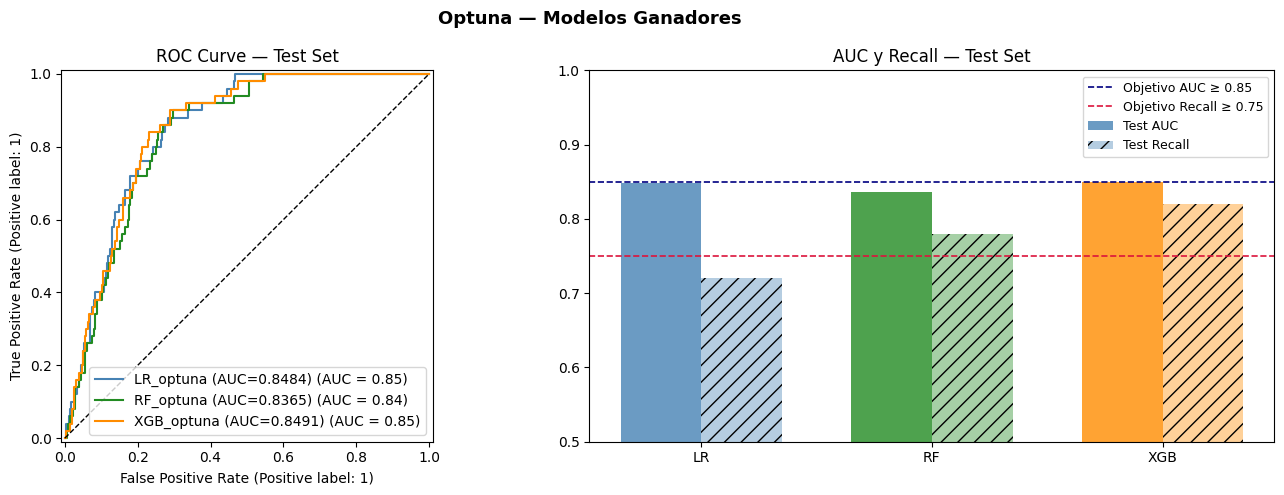

In [ ]:
# ── Curvas ROC comparativas ──
colors = {'LR_optuna': 'steelblue', 'RF_optuna': 'forestgreen', 'XGB_optuna': 'darkorange'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optuna — Modelos Ganadores', fontsize=13, fontweight='bold')

# ROC curves
for r in optuna_final_results:
    RocCurveDisplay.from_predictions(
        r['_y_test'], r['_y_prob'],
        name=f"{r['model']} (AUC={r['auc']:.4f})",
        ax=axes[0],
        color=colors.get(r['model'], 'gray')
    )
axes[0].set_title('ROC Curve — Test Set')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)

# Métricas barras
labels    = [r['model'].replace('_optuna', '') for r in optuna_final_results]
auc_vals  = [r['auc'] for r in optuna_final_results]
rec_vals  = [r['recall'] for r in optuna_final_results]

x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, auc_vals, w, label='Test AUC',    color=[colors[f'{l}_optuna'] for l in labels], alpha=0.8)
axes[1].bar(x + w/2, rec_vals, w, label='Test Recall', color=[colors[f'{l}_optuna'] for l in labels], alpha=0.4, hatch='//')
axes[1].axhline(0.85, linestyle='--', color='navy',   lw=1.2, label='Objetivo AUC ≥ 0.85')
axes[1].axhline(0.75, linestyle='--', color='crimson', lw=1.2, label='Objetivo Recall ≥ 0.75')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('AUC y Recall — Test Set')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'optuna_roc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

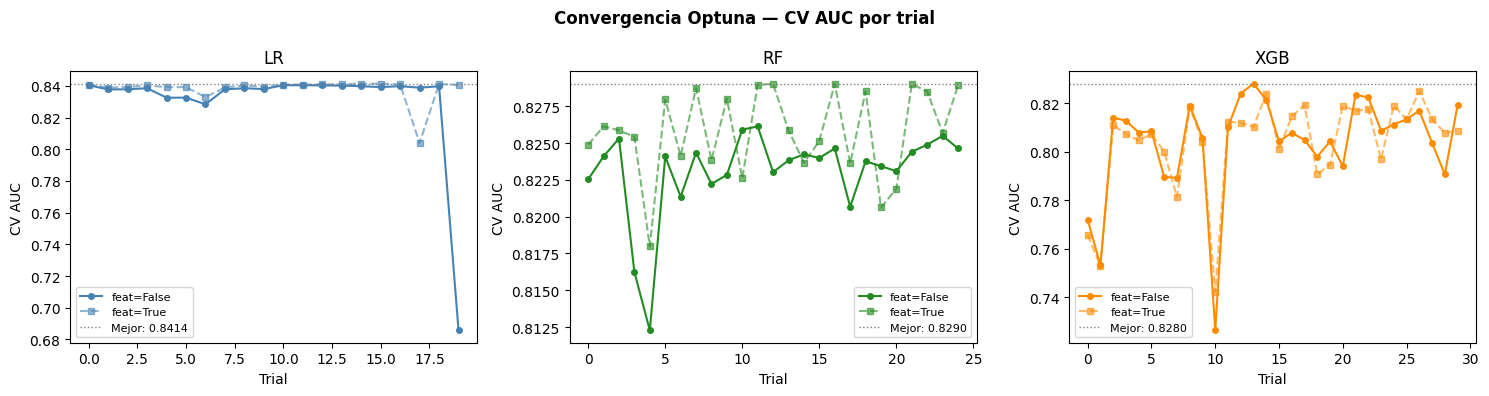

In [ ]:
# ── Convergencia de los 6 estudios ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Convergencia Optuna — CV AUC por trial', fontsize=12, fontweight='bold')

study_pairs = [
    ('LR',  study_lr_nofeat,  study_lr_feat,  'steelblue'),
    ('RF',  study_rf_nofeat,  study_rf_feat,  'forestgreen'),
    ('XGB', study_xgb_nofeat, study_xgb_feat, 'darkorange'),
]

for ax, (name, s_nofeat, s_feat, color) in zip(axes, study_pairs):
    vals_nofeat = [t.value for t in s_nofeat.trials]
    vals_feat   = [t.value for t in s_feat.trials]

    ax.plot(vals_nofeat, 'o-', color=color, lw=1.5, ms=4, label='feat=False')
    ax.plot(vals_feat,   's--', color=color, lw=1.5, ms=4, alpha=0.6, label='feat=True')
    ax.axhline(max(s_nofeat.best_value, s_feat.best_value),
               linestyle=':', color='gray', lw=1, label=f'Mejor: {max(s_nofeat.best_value, s_feat.best_value):.4f}')
    ax.set_title(f'{name}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV AUC')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'optuna_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 13 Métricas comparativas de modelo final
Vamos a usar :Feature Importance del modelo ganador y así se adpte automáticamente al tipo de ganador:  
- **XGB / RF** → `feature_importances_` (ganancia relativa por feature)  
- **LR** → `|coef_|` (valor absoluto de los coeficientes L1)


In [ ]:
# ── Identificar el ganador global (mejor TEST AUC entre los 3) ──
global_winner = max(optuna_final_results, key=lambda r: (r['auc'], r['recall']))
pipeline_w    = global_winner['_pipeline']
family_w = global_winner['model'].replace('_optuna', '')
add_feat_w    = global_winner['add_features']

print(f'Ganador global: {family_w}_optuna | add_features={add_feat_w}')
print(f'TEST AUC: {global_winner["auc"]:.4f} | TEST Recall: {global_winner["recall"]:.4f}')

"""
# ── Guardar pipeline ganador en disco ─────────────────────────────────────────
MODEL_DIR = Path('..') / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH     = MODEL_DIR / f'best_model_{family_w.lower()}_optuna.joblib'
THRESHOLD_PATH = MODEL_DIR / 'best_threshold.txt'

joblib.dump(pipeline_w, MODEL_PATH)
THRESHOLD_PATH.write_text(str(global_winner['threshold']))

print(f'\n✓ Modelo guardado   : {MODEL_PATH}')
print(f'✓ Threshold guardado: {global_winner["threshold"]}')

"""

Ganador global: XGB_optuna | add_features=False
TEST AUC: 0.8491 | TEST Recall: 0.8200


'\n# ── Guardar pipeline ganador en disco ─────────────────────────────────────────\nMODEL_DIR = Path(\'..\') / \'models\'\nMODEL_DIR.mkdir(parents=True, exist_ok=True)\n\nMODEL_PATH     = MODEL_DIR / f\'best_model_{family_w.lower()}_optuna.joblib\'\nTHRESHOLD_PATH = MODEL_DIR / \'best_threshold.txt\'\n\njoblib.dump(pipeline_w, MODEL_PATH)\nTHRESHOLD_PATH.write_text(str(global_winner[\'threshold\']))\n\nprint(f\'\n✓ Modelo guardado   : {MODEL_PATH}\')\nprint(f\'✓ Threshold guardado: {global_winner["threshold"]}\')\n\n'

In [ ]:
def get_feature_names_from_pipeline(pipeline, X_sample: pd.DataFrame) -> list:
    """
    Extrae los nombres de features tras el ColumnTransformer.
    Maneja el OHE de categóricas: devuelve nombres en formato 'col_valor'.
    """
    prep = pipeline.named_steps['prep']

    feature_names = []
    for name, transformer, cols in prep.transformers_:
        if name == 'remainder':
            continue
        if transformer == 'passthrough':
            feature_names.extend(cols)
        elif hasattr(transformer, 'get_feature_names_out'):
            # OneHotEncoder o StandardScaler
            try:
                ohe_names = transformer.get_feature_names_out(cols)
                feature_names.extend(ohe_names)
            except Exception:
                feature_names.extend(cols)
        else:
            feature_names.extend(cols)

    return feature_names


def get_feature_importance(pipeline, X_sample: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    """
    Extrae importancia de features adaptándose al modelo del pipeline.
    Retorna (DataFrame ordenado, label_eje_x).
    """
    clf = pipeline.named_steps['model']
    feature_names = get_feature_names_from_pipeline(pipeline, X_sample)

    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        label = f'Feature Importance ({type(clf).__name__.replace("Classifier", "")})'
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0])
        label = 'Coeficiente absoluto (LR — L1)'
    else:
        raise ValueError(f'Modelo {type(clf).__name__} no tiene feature importance disponible.')

    n = min(len(importances), len(feature_names))
    df_imp = pd.DataFrame({'feature': feature_names[:n], 'importance': importances[:n]})

    # Limpiar nombres OHE: 'cat__gender_Male' → 'gender_Male'
    df_imp['feature'] = df_imp['feature'].str.replace(r'^(cat|num)__', '', regex=True)

    return df_imp.sort_values('importance', ascending=False), label


# ── Dataset del ganador para extraer nombres de columnas ──
df_w    = get_dataset('full', add_features=add_feat_w)
X_w     = df_w.drop('stroke', axis=1)
X_train_w, _, _, _ = train_test_split(X_w, df_w['stroke'], stratify=df_w['stroke'],
                                      test_size=TEST_SIZE, random_state=RANDOM_STATE)

df_imp, imp_label = get_feature_importance(pipeline_w, X_train_w)

print('Top 5 features:')
print(df_imp.head().to_string(index=False))

✓ Dataset 'full' | add_features=False: 4,981 filas
Top 5 features:
              feature  importance
                  age    0.216921
         hypertension    0.087036
      ever_married_No    0.073684
    avg_glucose_level    0.059753
work_type_not_applied    0.058982


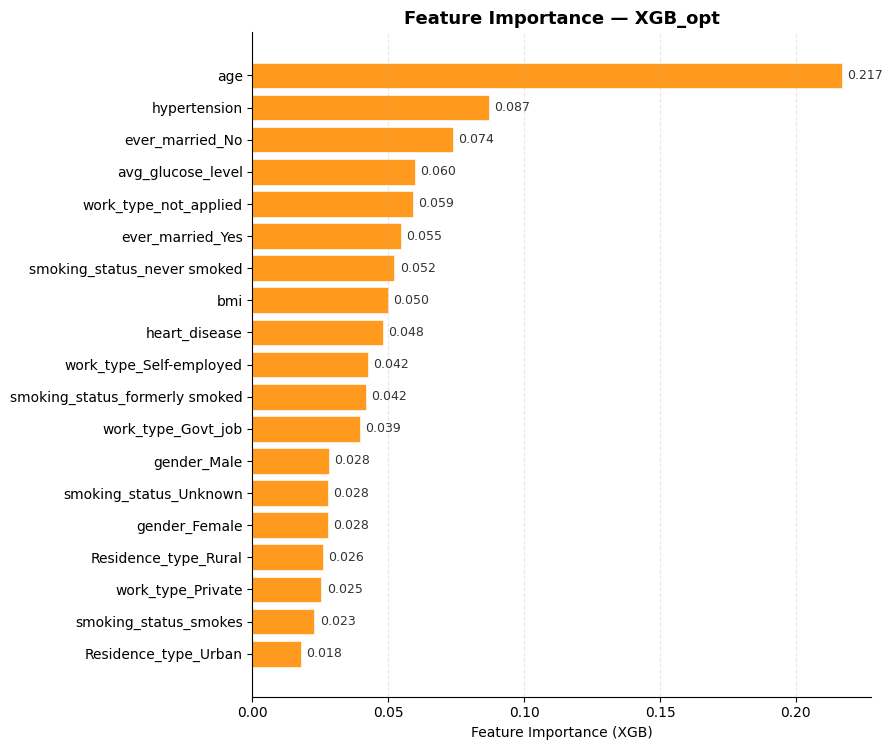

In [ ]:
# ── Gráfico Feature Importance ──
COLOR_MAP = {'LR': 'steelblue', 'RF': 'forestgreen', 'XGB': 'darkorange'}
bar_color = COLOR_MAP.get(family_w, 'steelblue')

fig, ax = plt.subplots(figsize=(9, max(5, len(df_imp) * 0.4)))

bars = ax.barh(df_imp['feature'], df_imp['importance'],
               color=bar_color, alpha=0.88, edgecolor='white', linewidth=0.5)
ax.invert_yaxis()

# Valores en cada barra
for bar, val in zip(bars, df_imp['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=9, color='#333')

ax.set_xlabel(imp_label)
ax.set_title(f'Feature Importance — {family_w}_opt', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(ASSETS_DIR / f'feature_importance_{family_w.lower()}.png', dpi=120, bbox_inches='tight')
plt.show()

### 13.1 Resumen 

In [ ]:
# ── Resumen textual ──
w = global_winner
sep = '─' * 60

auc_ok    = '✓' if w['auc']     >= 0.85 else '✗'
recall_ok = '✓' if w['recall']  >= 0.75 else '✗'
gap_ok    = '✓' if w['auc_gap'] <  0.05 else '✗'

print(sep)
print('RESUMEN · Optuna — Modelo Ganador')
print(sep)
print(f"  {'Modelo':20s}: {w['model']}")
print(f"  {'add_features':20s}: {w['add_features']}")
print(f"  {'threshold':20s}: {w['threshold']}")
print(sep)
print(f"  {'cv_auc':20s}: {w['cv_auc']}")
print(f"  {'cv_recall':20s}: {w['cv_recall']}")
print(sep)
print(f"  {'test_auc':20s}: {w['auc']}")
print(f"  {'test_recall':20s}: {w['recall']}")
print(f"  {'test_f1':20s}: {w['f1']}")
print(f"  {'test_precision':20s}: {w['precision']}")
print(f"  {'test_pr_auc':20s}: {w['pr_auc']}")
print(f"  {'auc_gap':20s}: {w['auc_gap']}")
print(sep)
print('Hiperparámetros Optuna:')
for k, v in w['best_params'].items():
    print(f"  {k:20s}: {v}")
print(sep)
print('Objetivos del proyecto:')
print(f'  AUC  ≥ 0.85   : {auc_ok} ({w["auc"]})')
print(f'  Recall ≥ 0.75 : {recall_ok} ({w["recall"]})')
print(f'  AUC Gap < 0.05: {gap_ok} ({w["auc_gap"]})')
print(sep)

────────────────────────────────────────────────────────────
RESUMEN · Optuna — Modelo Ganador
────────────────────────────────────────────────────────────
  Modelo              : XGB_optuna
  add_features        : False
  threshold           : 0.53
────────────────────────────────────────────────────────────
  cv_auc              : 0.828
  cv_recall           : 0.7787
────────────────────────────────────────────────────────────
  test_auc            : 0.8491
  test_recall         : 0.82
  test_f1             : 0.2645
  test_precision      : 0.1577
  test_pr_auc         : 0.1719
  auc_gap             : 0.0211
────────────────────────────────────────────────────────────
Hiperparámetros Optuna:
  n_estimators        : 196
  max_depth           : 3
  learning_rate       : 0.01374894555331037
  subsample           : 0.7390533721986331
  colsample_bytree    : 0.6999018540590647
  reg_alpha           : 6.764752472270359e-05
  reg_lambda          : 0.025574091808629934
───────────────────────